<a href="https://colab.research.google.com/github/toshikis/AISeminar/blob/%E5%8F%97%E8%AC%9B%E7%94%9F%E7%94%A8%E6%95%99%E6%9D%90/AI%E3%81%AE%E3%81%9F%E3%82%81%E3%81%AEPython%E5%85%A5%E9%96%80Level3_%E5%8F%97%E8%AC%9B%E7%94%9F%E7%94%A8_%E6%9D%89%E5%B1%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # <font color=#0e89b2>0. ライブラリのインポート</font>

このセクションで必要なライブラリは、ここでまとめてインポートしておくと便利です。

In [ ]:
! pip install japanize_matplotlib    # 日本語で描画できるようにするライブラリ
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from random import random, randint, sample

 # <font color=#0e89b2>1. Level3でのゴール</font>

Level3では、エージェント2人が街の中を移動して、濃厚接触範囲内に入った場合には一定確率で感染する処理を実装していきます。<br>
また、感染後1週間経過時に治癒する仕様や、マスクの着用有無によって感染率が変わる仕様も実装していきます。

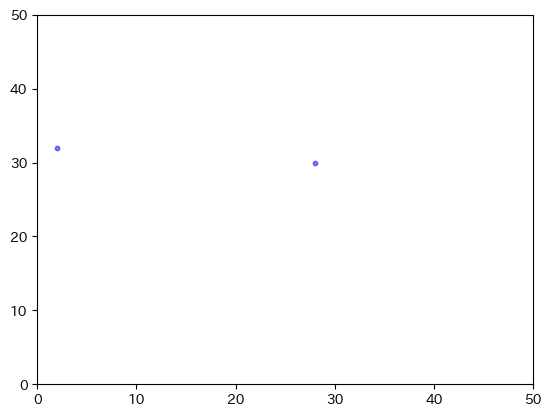

In [ ]:
#このコードは難読化されています。
a1 = {'x': 30, 'y': 30, 'dx': 1, 'dy': 0, 'inf': True, 'timer': 0, 'mask': True}
a2 = {'x': 40, 'y': 32, 'dx': -1, 'dy': 0, 'inf': False, 'timer': 0, 'mask': False}
g, s, irm, irnm = 50, 40, 0.1, 0.8

def uis(a):
    if a['inf']:
        a['timer'] += 1; a['inf'] = False if a['timer'] >= 7 else a['inf']; a['timer'] = 0 if a['timer'] >= 7 else a['timer']
    return a

def ma(a):
    if a['x'] == 0 or a['x'] == g: a['dx'] *= -1
    if a['y'] == 0 or a['y'] == g: a['dy'] *= -1
    a['x'] += a['dx']; a['y'] += a['dy']
    return a

def si(a1, a2, irm, irnm):
    ir = irm if a1['mask'] or a2['mask'] else irnm
    if not a2["inf"] and abs(a1['x'] - a2['x']) <= 2 and abs(a1['y'] - a2['y']) <= 2 and random() < ir: a2['inf'] = True
    return a2

def sa(a1, a2):
    for a in [a1, a2]: plt.scatter(a["x"], a["y"], s=10, color="red" if a["inf"] else "blue", alpha=0.5)

def ua(frame, a1, a2, irm, irnm):
    a1, a2 = uis(a1), uis(a2)
    a1, a2 = ma(a1), ma(a2)
    a2 = si(a1, a2, irm, irnm)
    plt.clf(); plt.xlim(0, g); plt.ylim(0, g); sa(a1, a2)

fig = plt.figure()
ani = FuncAnimation(fig, ua, fargs=(a1, a2, irm, irnm), frames=range(s), interval=100)
HTML(ani.to_jshtml())

 # <font color=#0e89b2>2. 健常者と罹患者を区別する</font>

ここでは、エージェントを「健常者」と「罹患者」に区別する処理を実装していきます。<br>
「健常者」と「罹患者」を区別するために、エージェントの情報保管用の例の辞書に、`is_infected`というキーも追加しましょう。<br>
以下のような対応関係とします。
* `is_infected: True`：健常者
* `is_infected: False`：罹患者

In [ ]:
agent1 = {
    "x":20,
    "y":30,
    "dx":1,
    "dy":0,
    "is_infected":True
}

In [ ]:
agent2 = {
    "x":50,
    "y":32,
    "dx":-1,
    "dy":0,
    "is_infected":False
}

 ## <font color=#0e89b2>◆実装</font>

上の2名のエージェントを、`grid_size=100`の街の中に描画します。<br>
健常者は青(`color=blue`)、罹患者は赤(`color=red`)で描画してください。<br>
静止画でOKです。

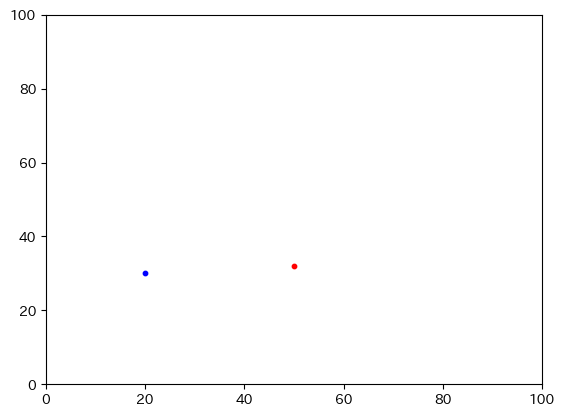

In [ ]:
grid_size = 100
# 枠
fig = plt.figure()
plt.xlim(0,grid_size)
plt.ylim(0,grid_size)
# 人
agents = [agent1,agent2]
for agent in agents:
  if agent["is_infected"]:
    plt.scatter(agent["x"], agent["y"], s=10, color="blue" )
  else:
    plt.scatter(agent["x"], agent["y"], s=10, color="red" )


 # <font color=#0e89b2>3. ウィルスを感染させる</font>

 ## <font color=#0e89b2>3.1 2マス以内に近づいたら感染させる</font>

 ### <font color=#0e89b2>a. 2マス以内の距離にいたら感染</font>

いよいよ感染の処理を実装していきます。<br>
まずは、どうすればエージェント同士が感染するか、基準を確認しておきます。

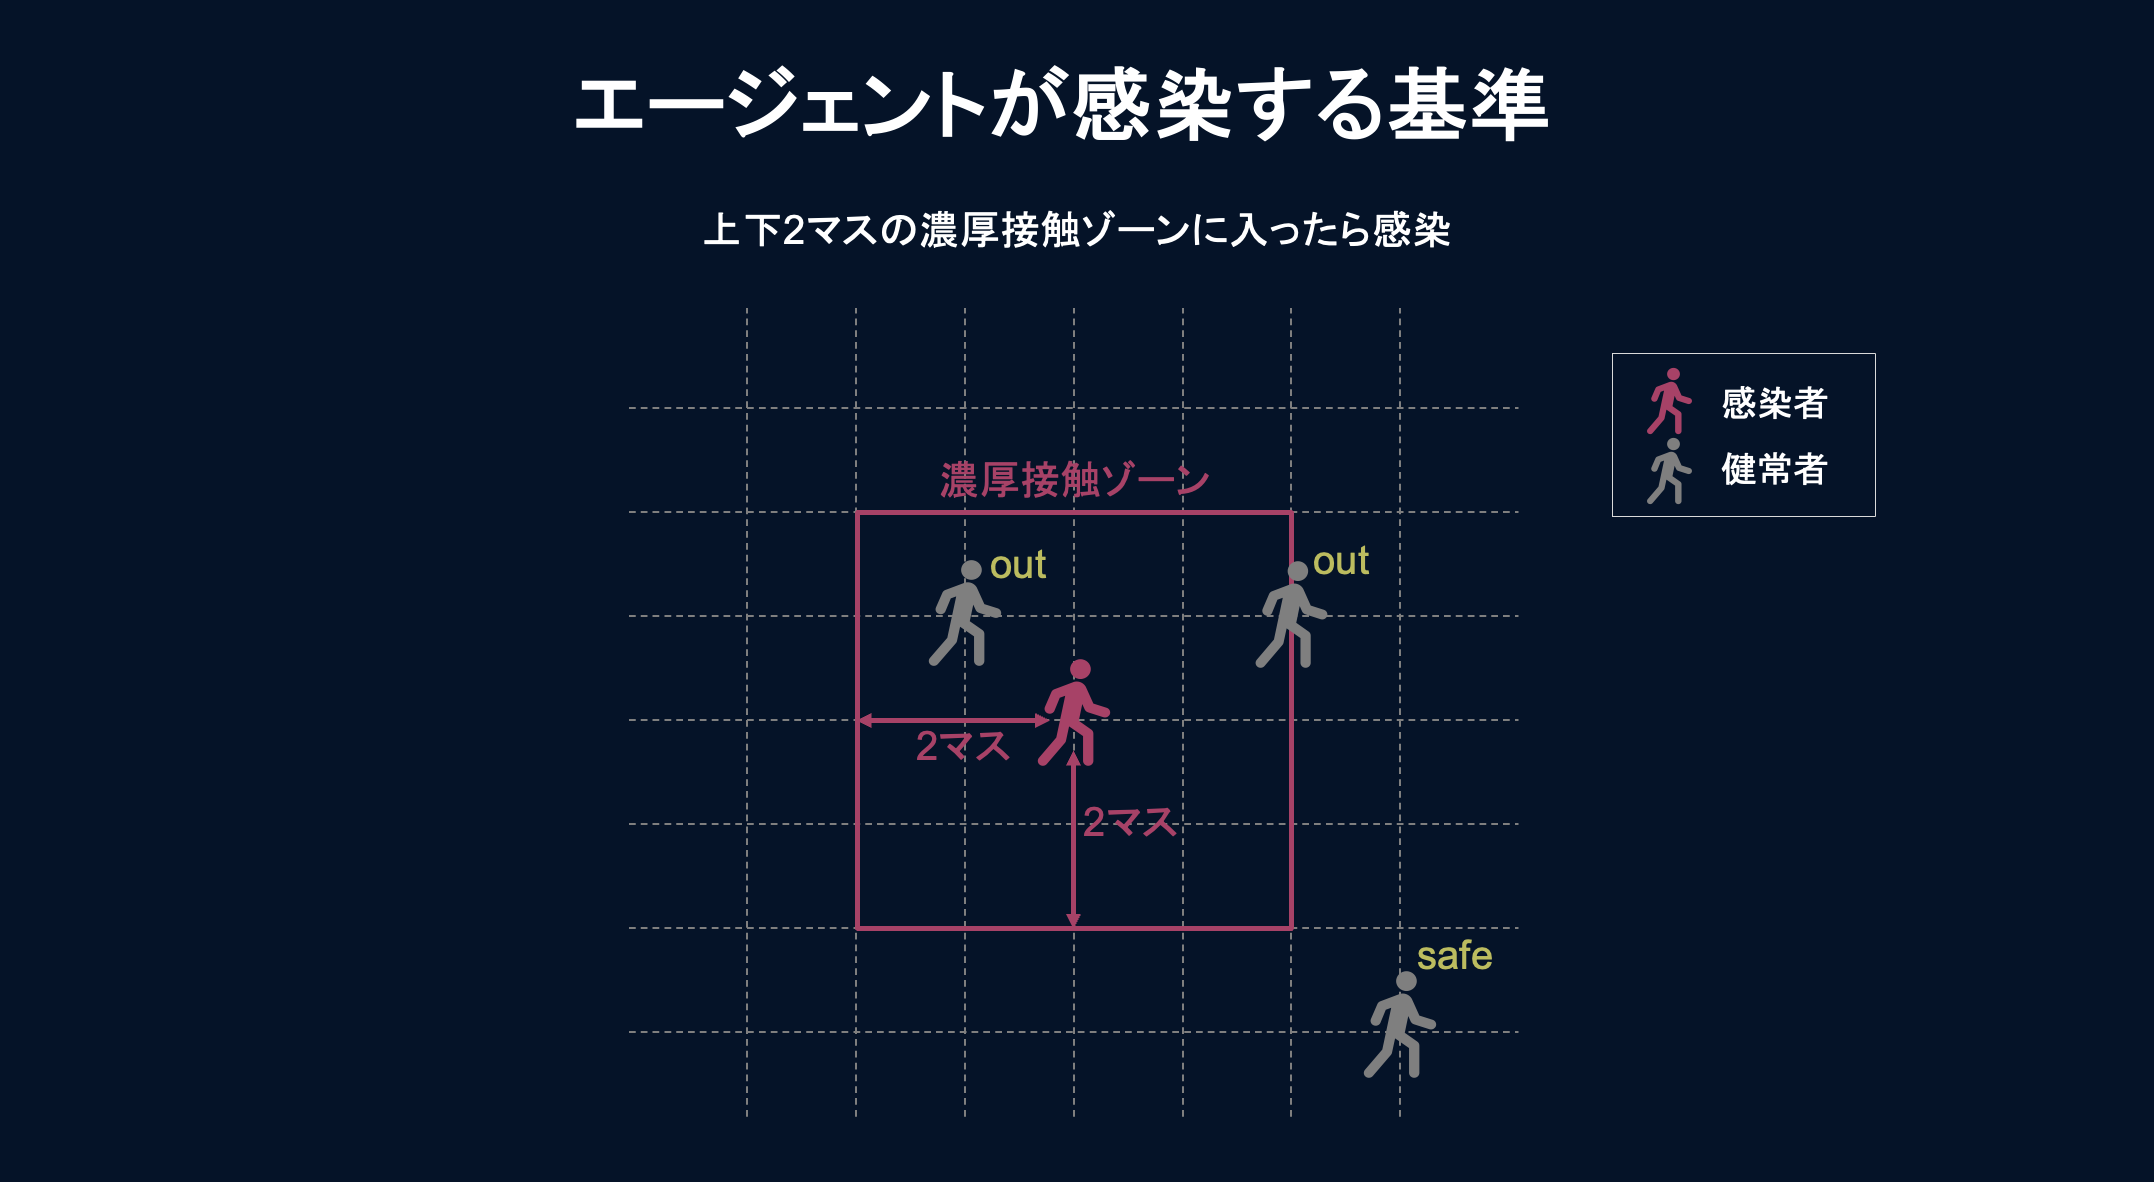

図のように、水平方向に2マス以内かつ垂直方向に2マス以内の距離にいたら「濃厚接触」と判定することにします。<br>
いずれかのエージェントが感染しており、他のエージェントと濃厚接触した場合は、他のエージェントに感染することとします。

 #### <font color=#0e89b2>◆実装</font>

以下の3名のサンプルエージェントを使って、濃厚接触の判定を行うコードを実装していきます。

In [ ]:
agent1 = {
    'x': 20,
    'y': 30,
    'dx': 1,
    'dy': 0,
    'is_infected': True}

In [ ]:
agent2 = {
    'x': 50,
    'y': 32,
    'dx': -1,
    'dy': 0,
    'is_infected': False}

In [ ]:
agent3 = {
    'x': 19,
    'y': 32,
    'dx': -1,
    'dy': 0,
    'is_infected': False}

(1) 以下の処理を行うコードを書いてください。<br>
`agent1`と`agent2`が濃厚接触している場合、`濃厚接触`と出力する。<br>
条件<br>
* 絶対値を返す`abs()`関数を使いましょう。例）`abs(-3)`→出力結果`3`、`abs(2)`→出力結果`2`


In [ ]:
if  abs(agent1["x"] - agent2["x"]) <= 2 and abs(agent1["y"] - agent2["y"] ) <= 2:
  print("濃厚接触")
else:
  print("非接触")

非接触


(2) (1)のように、2人のエージェントが濃厚接触の範囲内にいるかを判定する関数を作成してください。<br>
ここでは、距離を判定するのみで、感染ステータスの変更は行わなくて結構です。<br>
条件<br>
* 濃厚接触の範囲内にいる場合はTrueを、していない場合はFalseを返してください。
* 関数名は`distance_judge()`としてください。
* 引数には`agent1`(辞書)と`agent2`(辞書)を渡してください。

In [ ]:
def distance_judge(_agent1,_agent2):
  if abs(_agent1["x"] - _agent2["x"]) <= 2 and abs(_agent1["y"] - _agent2["y"]) <= 2:
    return True
  else:
    return False

In [ ]:
distance_judge(agent1,agent2)

In [ ]:
distance_judge(agent1,agent3)

 ### <font color=#0e89b2>b. 移動していって2マス以内に入ったら感染</font>

次は、エージェントが移動する処理と、移動しながら濃厚接触範囲内に入ったら感染する処理を組み合わせていきましょう。

 #### <font color=#0e89b2>◆実装</font>

(1) 以下の2名のエージェント（サンプルコードが用意されています）を歩かせて、<br>
濃厚接触範囲内に入ったら`agent2`を感染させるコードを書いてください。<br>関数化はまだしなくてOKです。<br>
条件
* 歩数は`steps=30`、街のサイズは`grid_size=50`で定義してください。
* エージェントが移動する処理は、Level2で実装した`move_agents()`関数を使用してください。
* 濃厚接触範囲内に入ったかどうかの判定は、先ほど実装した`distance_judge()`関数を使用してください。
* 濃厚接触範囲内に入った場合は、`agent2`の`is_infected`ステータスを`True`に変更した上で、`agent2が感染しました`という文字列と、感染した場所のx座標とy座標を`print()`で出力してください。

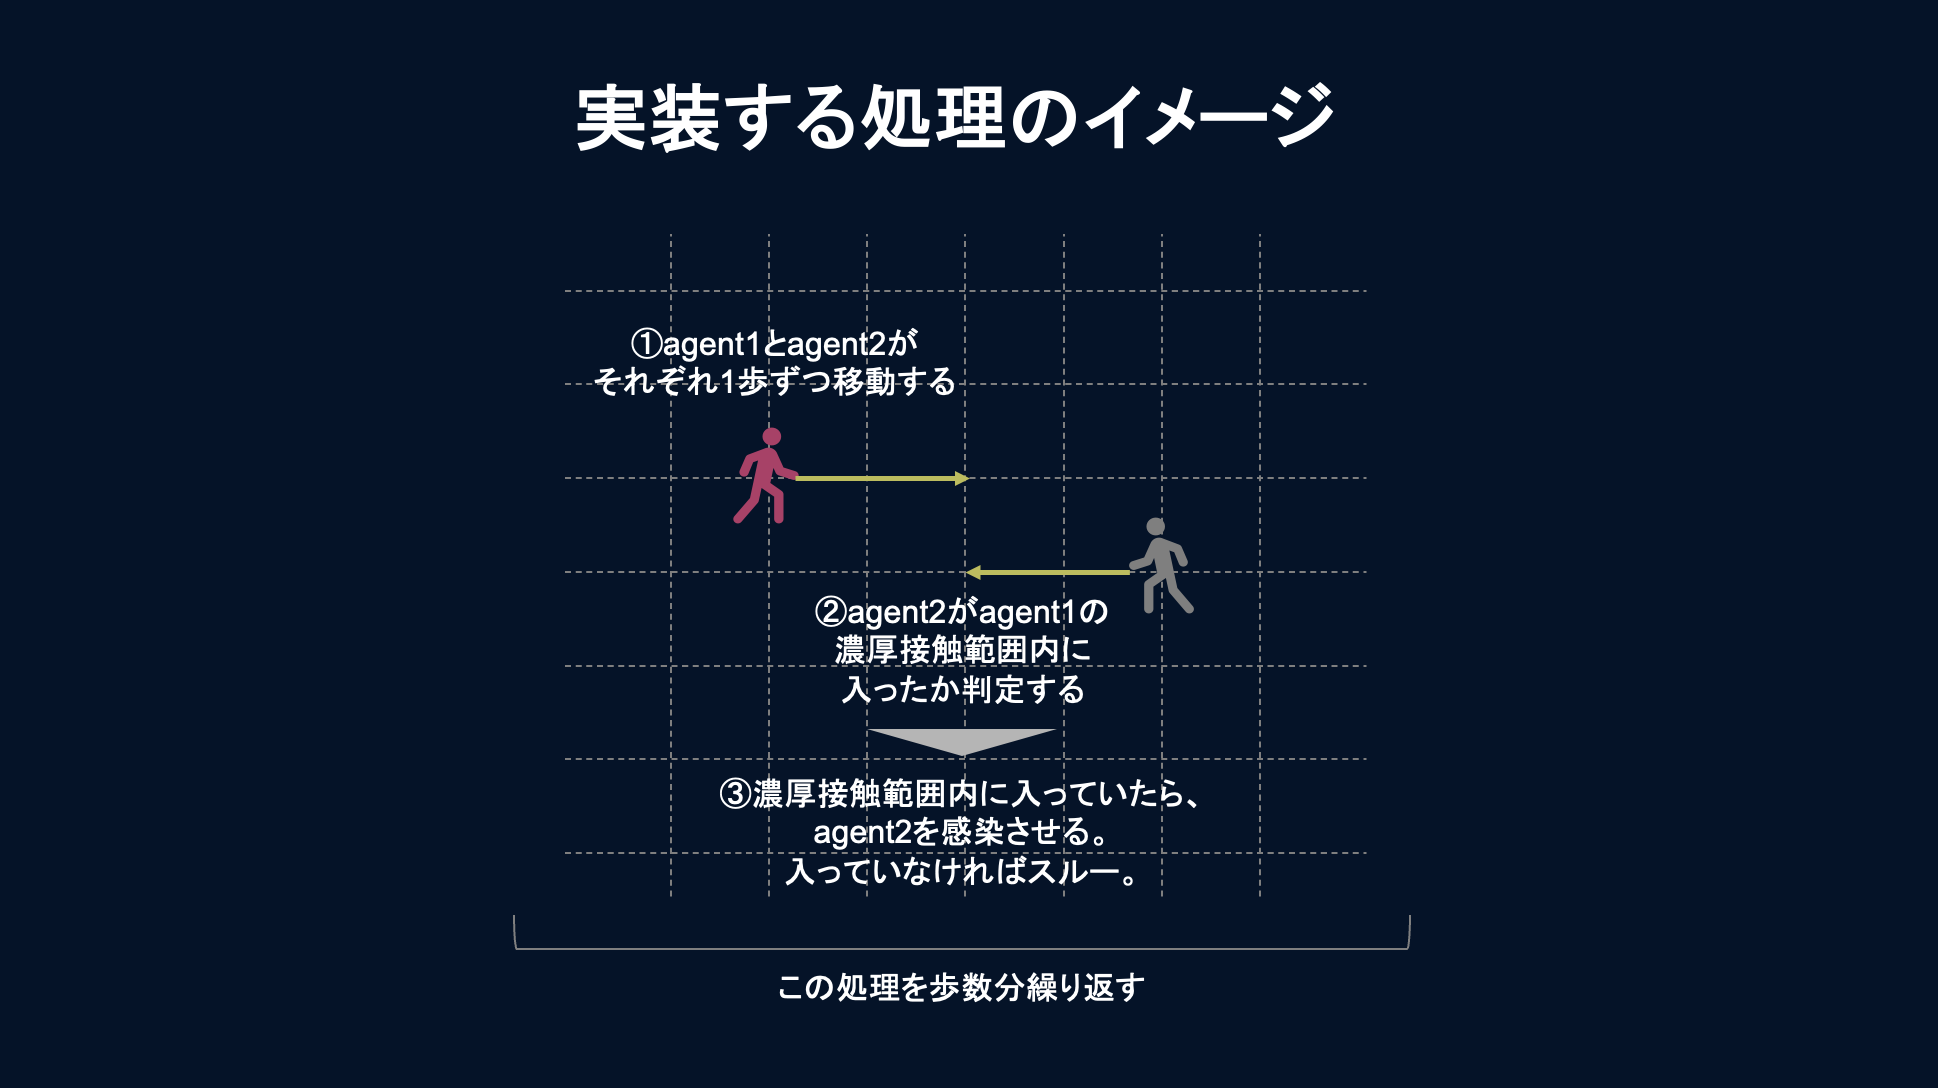

In [ ]:
agent1 = {
    'x': 20,
    'y': 30,
    'dx': 1,
    'dy': 0,
    'is_infected': True}
agent2 = {
    'x': 30,
    'y': 32,
    'dx': -1,
    'dy': 0,
    'is_infected': False}

In [ ]:
## 関数１
def move_agents(_agent):
  if _agent['x'] == 0 or _agent['x'] == grid_size:
      _agent['dx'] *= -1
  if _agent["y"] == 0 or _agent["y"] == grid_size:
      _agent['dy'] *= -1
  #移動
  _agent['x'] += _agent['dx'] #エージェントの位置（x座標）を更新
  _agent['y'] += _agent['dy'] #エージェントの位置（y座標）を更新
  return _agent
## 関数２
def distance_judge(agent1, agent2):
    distance_x = abs(agent1['x'] - agent2['x'])
    distance_y = abs(agent1['y'] - agent2['y'])
    # 感染可能な距離内にいる場合はTrue、そうでなければFalseを返す
    if distance_x <= 2 and distance_y <= 2:
      return True
    else:
      return False

## メイン
# 変数
steps=30
grid_size = 70

# steps分実行
for _ in range(steps):
  #進路を変更
  agent1 = move_agents(agent1)
  agent2 = move_agents(agent2)
  if distance_judge(agent1, agent2):
    agent2['is_infected'] = False  # 感染する
    print("agent2が感染しました"," x座標＝",agent2["x"]," y座標＝",agent2["y"])


agent2が感染しました  x座標＝ 26  y座標＝ 32
agent2が感染しました  x座標＝ 25  y座標＝ 32
agent2が感染しました  x座標＝ 24  y座標＝ 32


(2) 上の指示通りそのまま実装すると、`agent2`が感染した後も繰り返し、<br>
「agent2が感染しました」の表示が出てしまうかと思います。<br>
この問題を解消するために、`agent2`が未感染の場合のみ、濃厚接触判定や感染処理を行うように<br>
コードを書き換えてください。

In [ ]:
agent1 = {
    'x': 20,
    'y': 30,
    'dx': 1,
    'dy': 0,
    'is_infected': True}
agent2 = {
    'x': 30,
    'y': 32,
    'dx': -1,
    'dy': 0,
    'is_infected': False}

In [ ]:
## 関数１
def move_agents(_agent):
  if _agent['x'] == 0 or _agent['x'] == grid_size:
      _agent['dx'] *= -1
  if _agent["y"] == 0 or _agent["y"] == grid_size:
      _agent['dy'] *= -1
  #移動
  _agent['x'] += _agent['dx'] #エージェントの位置（x座標）を更新
  _agent['y'] += _agent['dy'] #エージェントの位置（y座標）を更新
  return _agent
## 関数２
def distance_judge(agent1, agent2):
    distance_x = abs(agent1['x'] - agent2['x'])
    distance_y = abs(agent1['y'] - agent2['y'])
    # 感染可能な距離内にいる場合はTrue、そうでなければFalseを返す
    if distance_x <= 2 and distance_y <= 2:
      return True
    else:
      return False

## メイン
# 変数
steps=30
grid_size = 70

# steps分実行
for _ in range(steps):
  #進路を変更
  agent1 = move_agents(agent1)
  agent2 = move_agents(agent2)
  if agent2["is_infected"] == True:
    if distance_judge(agent1, agent2):
      agent2['is_infected'] = False  # 感染する
      print("agent2が感染しました"," x座標＝",agent2["x"]," y座標＝",agent2["y"])

(3) 上の処理をアニメーション化しましょう。<br>
具体的には、以下のような挙動をアニメーション化してください。
* `agent1`と`agent2`が一歩ずつ移動する（壁に当たったら方向転換する）。
* `agent1`は常に感染状態。青い点で描画する。
* `agent2`(デフォルトでは未感染）は、`agent1`の濃厚接触範囲内に入ると感染状態に変わる。未感染時は青い点で描画し、感染時は赤い点で描画する。

条件
* `grid_size=50`（街のサイズはこれで指定）
* `steps=40`（歩数はこれで指定）
* `agent1 = {'x': 20, 'y': 30, 'dx': 1, 'dy': 0, 'is_infected': True}`
* `agent2 = {'x': 40, 'y': 32, 'dx': -1, 'dy': 0, 'is_infected': False}`

<br>

ヒント
* 関数`update_animation()`は`agent1`と`agent2`を引数に受け取ると良いです。
* `agent1`は常に`plt.scatter(agent1["x"], agent1["y"], color="blue")`で描画すればOK。
* 一方`agent2`は条件分岐で`plt.scatter(略、color="blue")`と`plt.scatter(略、color="red")`を使い分けましょう。

In [ ]:
# あとからやる


 ## <font color=#0e89b2>3.2 2マス以内に近づいたら80%の確率で感染させる</font>

とはいえ現実的には、濃厚接触したからといって100%感染するわけではありません。<br>
そこでより現実の状況に近づけるために、濃厚接触時の感染確率を80%に調整しましょう。<br>
<br>
まずは、「一定の確率でXXする」という処理の実装方法を学びます。<br>
下のコードを見てみましょう。<br>
このコードを実行すると、50%の確率で「当たり」、50%の確率で「ハズレ」が出力されます。<br>
（試しに何度か実行してみてください）<br>
<br>
仕掛けとしては、`random()`関数が0から1までの値を均等な確率で返すので、<br>
`random()<0.5`が`True`になる確率は、理論上50%だというわけです。

In [ ]:
if random() < 0.5:
  print("当たり")
else:
  print("ハズレ")

当たり


 #### <font color=#0e89b2>◆実装</font>

7.1で実装したコードを一部だけ書き換えて、濃厚接触時の感染確率を80%に設定してください。<br>
条件
* 感染確率は`infection_rate`という変数で定義してください。
* `update_animation()`関数が`infection_rate`を引数として受け取るようにしてください。

<br>

ヒント
* `update_animation()`関数の引数は、`frame, agent1, agent2, infection_rate`になります。

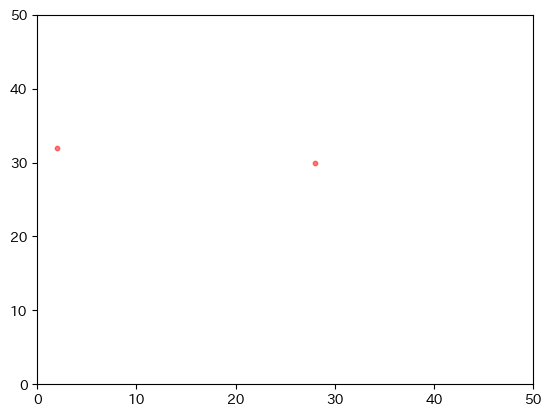

In [ ]:
agent1 = {
    'x': 30,
    'y': 30,
    'dx': 1,
    'dy': 0,
    'is_infected': True}

agent2 = {
    'x': 40,
    'y': 32,
    'dx': -1,
    'dy': 0,
    'is_infected': False}

infection_rate = 0.8
def update_animation(frame, agent1, agent2, infection_rate):
  # 次の移動先の決定
  agent1 = move_agents(agent1)
  agent2 = move_agents(agent2)

  #感染処理
  if not agent2["is_infected"]:              # 非接触者か
    if distance_judge(agent1, agent2):       # 感染する距離か
      if random() < infection_rate:          # 感染する確率
        agent2['is_infected'] = True

  plt.clf()
  plt.xlim(0, grid_size)
  plt.ylim(0, grid_size)

  #agent1を描画
  plt.scatter(agent1["x"], agent1["y"], s=10, color="red", alpha=0.5)

  #agent2を描画（感染すると赤に変わる）
  if agent2["is_infected"] == True:
    plt.scatter(agent2["x"], agent2["y"], s=10, color="red", alpha=0.5)
  else:
    plt.scatter(agent2["x"], agent2["y"], s=10, color="blue", alpha=0.5)

#各種パラメータの設定（ここでシミュレーションモデルのパラメータを変更できます）
grid_size = 50
steps = 40
infection_rate = 0.8

# アニメーションの作成
fig = plt.figure()
ani = FuncAnimation(fig, update_animation, fargs=(agent1, agent2, infection_rate), frames=range(steps), interval=1000)

# アニメーションの表示
HTML(ani.to_jshtml())

 # <font color=#0e89b2>4. 感染後1週間経ったら治癒させる</font>

ここまで`agent1`はずっと感染しっぱなし、`agent2`も一度感染するとその後感染しっぱなしの状況になってしまっています。<br>
しかし現実には一定期間経てば基本的には治癒するはずなので、この処理も実装しましょう。<br>
<br>
ここでは、感染後正味7日間が経過したら（つまり感染してから7コマ分進んだら）

 #### <font color=#0e89b2>◆実装</font>

(1) `agent1`、`agent2`の辞書共に、新たに`infection_timer`というキーを追加してください。<br>
デフォルトの値は0（つまり感染後0日経過）を設定しておきましょう。

In [ ]:
#infection_timerというキーを追加してください
agent1 = {
    'x': 30,
    'y': 30,
    'dx': 1,
    'dy': 0,
    'is_infected': True,
    'infection_timer':0}

agent2 = {
    'x': 40,
    'y': 32,
    'dx': -1,
    'dy': 0,
    'is_infected': False,
    'infection_timer':0}

(2) 上の`agent1`について、10コマ分（=10日分）時を進めて、7日経過時に治癒させる処理をコーディングしてください。<br>
■条件
* `for step in range(10):`で書き始めてください。
* 1日経過につき`infection_timer`を+1する。
* `infection_timer`が7になった時点で、`is_infected`を`False`に変更する。（同時に「X日目に治りました」といいう文字を出力する。）
* 治癒した場合は、`infection_timer`を0に戻す

In [ ]:
for step in range(10):
  agent1['infection_timer'] += 1
  if agent1['infection_timer'] == 7:
    agent1['is_infected'] = False
    print(step+1,"日目に治りました")
    agent1['infection_timer'] = 0

7 日目に治りました


(3) この1週間経ったら治癒する（1日ごとにタイマーを進める）という処理を関数化しておきましょう。<br>
■条件
* 関数名は、`update_infection_status()`としてください。
* 引数は、例の`agent`辞書を受け取るようにしてください。他の引数は取りません。
* 関数内では、以下の処理を実行するようにしてください。
 * もし引数で受け取った`agent`が罹患者であれば、タイマーを1日進める
 * もしタイマーが7になっていたら、受け取った`agent`の`is_infected`を`False`に、`infection_timer`を0に変更する。
* 返り値は、ステータス更新後の`agent`の辞書を返すようにして下さい。

■出力結果のイメージ
* 例えば `{'x': 20, 'y': 30, 'dx': 1, 'dy': 0, 'is_infected': True, 'infection_timer': 4}`のエージェントを受け取ると、返り値は`{'x': 20, 'y': 30, 'dx': 1, 'dy': 0, 'is_infected': True, 'infection_timer': 5}`になります。
* 例えば`{'x': 40, 'y': 32, 'dx': -1, 'dy': 0, 'is_infected': False}`のエージェントを受け取ると、何も変更せずそのまま返り値として返します。
* 例えば `{'x': 20, 'y': 30, 'dx': 1, 'dy': 0, 'is_infected': True, 'infection_timer': 6}`のエージェントを受け取ると、返り値は`{'x': 20, 'y': 30, 'dx': 1, 'dy': 0, 'is_infected': False, 'infection_timer': 0}`になります。

In [ ]:
# 関数：治療
def update_infection_status(agent):
  if agent['is_infected']:
    agent['infection_timer'] += 1
    if agent['infection_timer'] == 7:
      agent['is_infected'] = False
      agent['infection_timer'] = 0
  return agent


(4) 7.2で実装したコードに、(3)で実装した`update_infection_status()`関数を埋め込んで、<br>
感染後7日経過したら治癒するように改良しましょう。<br>
* (3)の実装例を下に示しており、`update_infection_status()`関数の埋め込み場所候補を「選択肢①」と「選択肢②」の2つ示しています。どちらに挿入するのが適切でしょうか？どのように挿入すると良いでしょうか？
* もう一箇所コードを書き換えるべき部分があります。どこをどのように書き換えると良いでしょうか？

実装できたらアニメーションを実行してみて、正しく感染や治癒の挙動が実装できているか、確認してみましょう。

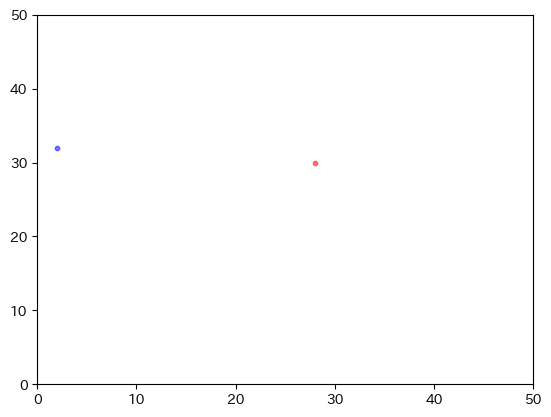

In [ ]:
agent1 = {
    'x': 30,
    'y': 30,
    'dx': 1,
    'dy': 0,
    'is_infected': True,
    'infection_timer': 0}

agent2 = {
    'x': 40,
    'y': 32,
    'dx': -1,
    'dy': 0,
    'is_infected': False,
    'infection_timer': 0}

def update_animation(frame, agent1, agent2, infection_rate):
  ############
  ###選択肢①###
  ############
  # 感染治療
  agent1 = update_infection_status(agent1)
  agent2 = update_infection_status(agent2)

  #移動
  agent1 = move_agents(agent1)
  agent2 = move_agents(agent2)

  #感染処理
  if not agent2["is_infected"]:
    if distance_judge(agent1, agent2):
      if random() < infection_rate:
        agent2['is_infected'] = True

  ############
  ###選択肢②###
  ############

  #描画
  plt.clf()
  plt.xlim(0, grid_size)
  plt.ylim(0, grid_size)

  #agent1とagent2をそれぞれ描画
  for agent in [agent1, agent2]:
    if agent["is_infected"] == True:
      plt.scatter(agent["x"], agent["y"], s=10, color="red", alpha=0.5)
    else:
      plt.scatter(agent["x"], agent["y"], s=10, color="blue", alpha=0.5)
  #agent1を描画
  plt.scatter(agent1["x"], agent1["y"], s=10, color="red", alpha=0.5)

  #agent2を描画（感染すると赤に変わる）
  if agent2["is_infected"] == True:
    plt.scatter(agent2["x"], agent2["y"], s=10, color="red", alpha=0.5)
  else:
    plt.scatter(agent2["x"], agent2["y"], s=10, color="blue", alpha=0.5)


#各種パラメータの設定（ここでシミュレーションモデルのパラメータを変更できます）
grid_size = 50
steps = 40
infection_rate = 0.8

# アニメーションの作成
fig = plt.figure()
ani = FuncAnimation(fig, update_animation, fargs=(agent1, agent2, infection_rate), frames=range(steps), interval=100)

# アニメーションの表示
HTML(ani.to_jshtml())

 # <font color=#0e89b2>5. マスクを着用させる</font>

最後に、このシミュレーションモデルにおいて重要な、「マスク着用率」という条件を追加します。<br>
ここまでは、濃厚接触した場合の感染率は一律で80%としていましたが、以下のようにアップデートしましょう。<br><br>
2人のエージェントが濃厚接触した場合の感染率
* いずれもマスクを着用していない場合：80%
* 少なくとも一方がマスクを着用していた場合：10%

## <font color=#0e89b2>5.1 マスクの着用有無を区別する</font>

まずは例によって、マスクの着用有無を示すキーを`agent`辞書に追加しましょう。

 #### <font color=#0e89b2>◆実装</font>

マスクの着用有無は、`wears_mask`というキーで管理することにします。<br>
また、着用している場合は`True`、着用していない場合は`False`の値を持たせることにします。<br>
以下の`agent`辞書に、上記のキーと値を追加してください。<br>
ただし、`agent1`はマスクを着用している、`agent2`はマスクを着用していないものとします。

In [ ]:
#マスクの着用有無を示すキーを追加してください
agent1 = {
    'x': 30,
    'y': 30,
    'dx': 1,
    'dy': 0,
    'is_infected': True,
    'infection_timer': 0,
    'wears_mask':True}

agent2 = {
    'x': 40,
    'y': 32,
    'dx': -1,
    'dy': 0,
    'is_infected': False,
    'infection_timer': 0,
    'wears_mask':False}

## <font color=#0e89b2>5.2 マスクを着用していれば濃厚接触でも感染率を10%にする</font>

 #### <font color=#0e89b2>◆実装</font>

(1) マスク着用状況によって感染率を変更する関数`calculate_infection_rate()`を実装してください。<br>
<br>
再掲になりますが、2人のエージェントが濃厚接触した場合の感染率は以下の通りです。
* いずれもマスクを着用していない場合：80%
* 少なくとも一方がマスクを着用していた場合：10%

これらの値は、それぞれ以下の変数を新しく設定して持たせることにします。
* `infection_rate_with_mask`：80%
* `infection_rate_without_mask`：10%

<br>

■条件
* 関数名は`calculate_infection_rate()`とします。
* 引数は、`agent1, agent2, infection_rate_with_mask, infection_rate_without_mask`の4つを受け取ることとします。
* 返り値は、少なくとも一方がマスクを着用している場合は`infection_rate_with_mask`を、いずれもマスクを着用していない場合は`infection_rate_without_mask`を返すこととします。

In [ ]:
def calculate_infection_rate(agent1, agent2, infection_rate_with_mask, infection_rate_without_mask):
  if agent1['wears_mask'] or agent2['wears_mask']:
    return infection_rate_with_mask
  else:
    return infection_rate_without_mask


(2) 8で実装したコードに、9.1と9.2(1)で実装したコードを上手く挿入して、<br>
マスク着用状況によって感染率が変わるようアニメーションをアップデートしてください。<br>
<br>
■条件
* `update_animation()`関数は、以下の引数を受け取ることとします。
 * `frame, agent1, agent2, infection_rate_with_mask, infection_rate_without_mask`

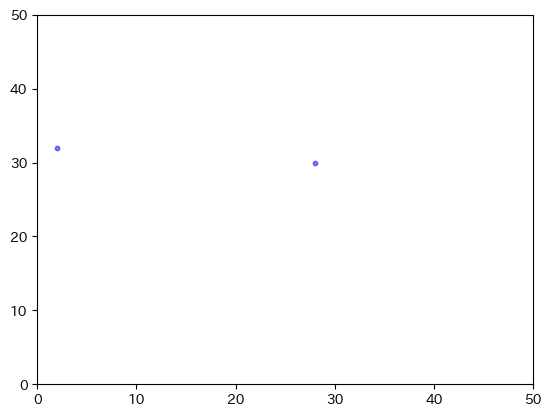

In [ ]:
agent1 = {
    'x': 30,
    'y': 30,
    'dx': 1,
    'dy': 0,
    'is_infected': True,
    'infection_timer': 0,
    'wears_mask':True}


agent2 = {
    'x': 40,
    'y': 32,
    'dx': -1,
    'dy': 0,
    'is_infected': False,
    'infection_timer': 0,
    'wears_mask':False}


def update_animation(frame, agent1, agent2, infection_rate_with_mask,infection_rate_without_mask):
  ############
  ###選択肢①###
  ############
  # 感染治療
  agent1 = update_infection_status(agent1)
  agent2 = update_infection_status(agent2)

  #移動
  agent1 = move_agents(agent1)
  agent2 = move_agents(agent2)

  #感染処理
  if not agent2["is_infected"]:
    if distance_judge(agent1, agent2):
      infection_rate = calculate_infection_rate(agent1, agent2, infection_rate_with_mask, infection_rate_without_mask)
      if random() < infection_rate:
        agent2['is_infected'] = True

  #描画
  plt.clf()
  plt.xlim(0, grid_size)
  plt.ylim(0, grid_size)

  #agent1とagent2をそれぞれ描画
  for agent in [agent1, agent2]:
    if agent["is_infected"] == True:
      plt.scatter(agent["x"], agent["y"], s=10, color="red", alpha=0.5)
    else:
      plt.scatter(agent["x"], agent["y"], s=10, color="blue", alpha=0.5)


#各種パラメータの設定（ここでシミュレーションモデルのパラメータを変更できます）
grid_size = 50
steps = 40
infection_rate_with_mask = 0.1
infection_rate_without_mask = 0.8

# アニメーションの作成
fig = plt.figure()
#ani = FuncAnimation(fig, update_animation, fargs=(agent1, agent2, 0.1, 0.8), frames=range(steps) , interval=100)
ani = FuncAnimation(fig, update_animation, fargs=(agent1, agent2, infection_rate_with_mask, infection_rate_without_mask), frames=range(steps), interval=100)

# アニメーションの表示
HTML(ani.to_jshtml())

 # <font color=#0e89b2>6. コードを整理する</font>

お疲れ様でした。Pythonに入門したばかりにも関わらず、いきなりこんな本格的なコードを書いて、大変だったと思います。<br>
<br>
実はここまでで、シミュレーションに必要なコードはほぼ実装し終わっています。<br>
ここまではエージェント2人だけの世界で移動や感染、治癒などの処理を実装してきましたが、<br>
ここから登場人物を1,000人に増やすだけです。<br>
(1,000人に増えても、ループ処理を回せばいいだけなので、ここからはそんなに大変ではありません）<br>
<br>
次のLevel4でこの1,000人にエージェントを増やす作業をしていくのですが、<br>
その前に一旦コードをなるべく綺麗に整理しておきましょう。

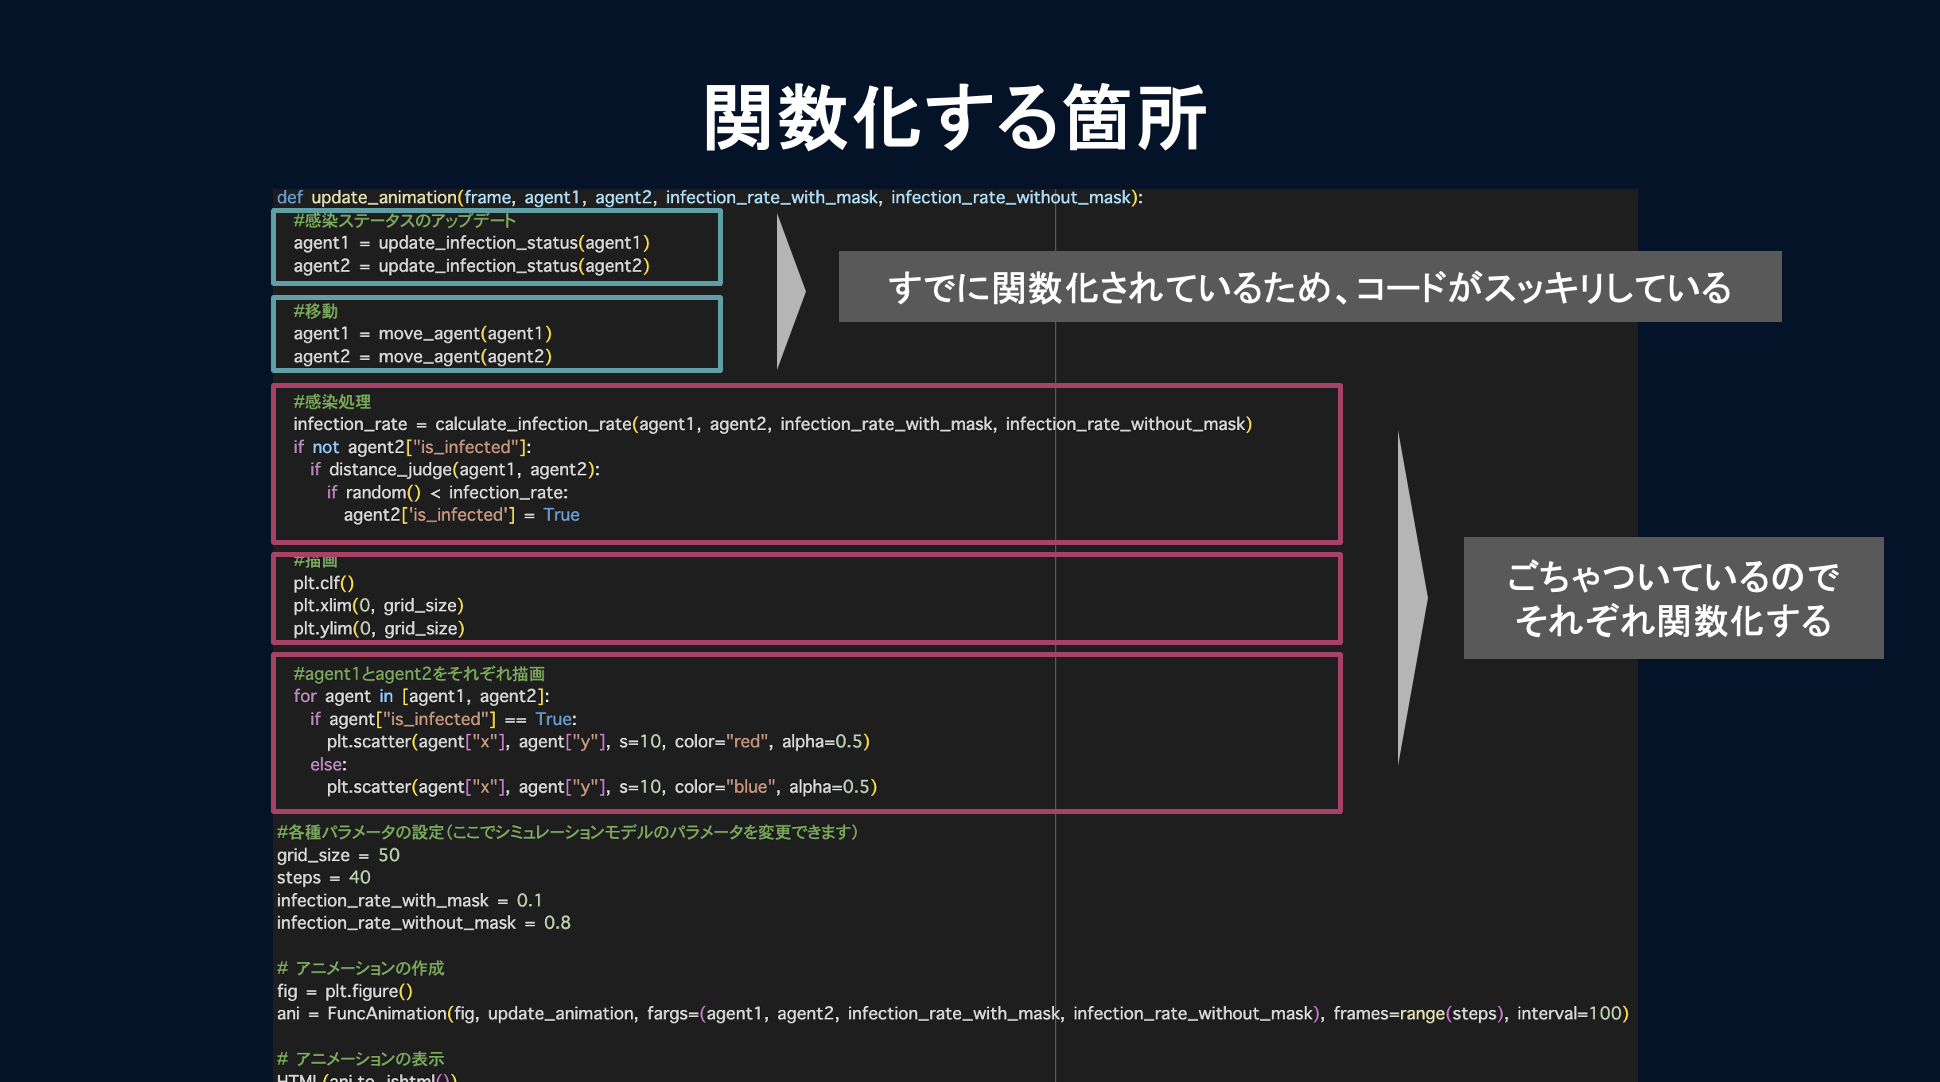

図の箇所を関数化することで、コードをすっきりさせていきます。<br>
このように、まとまった処理を関数化することを、モジュール化やカプセル化と呼んだりします。

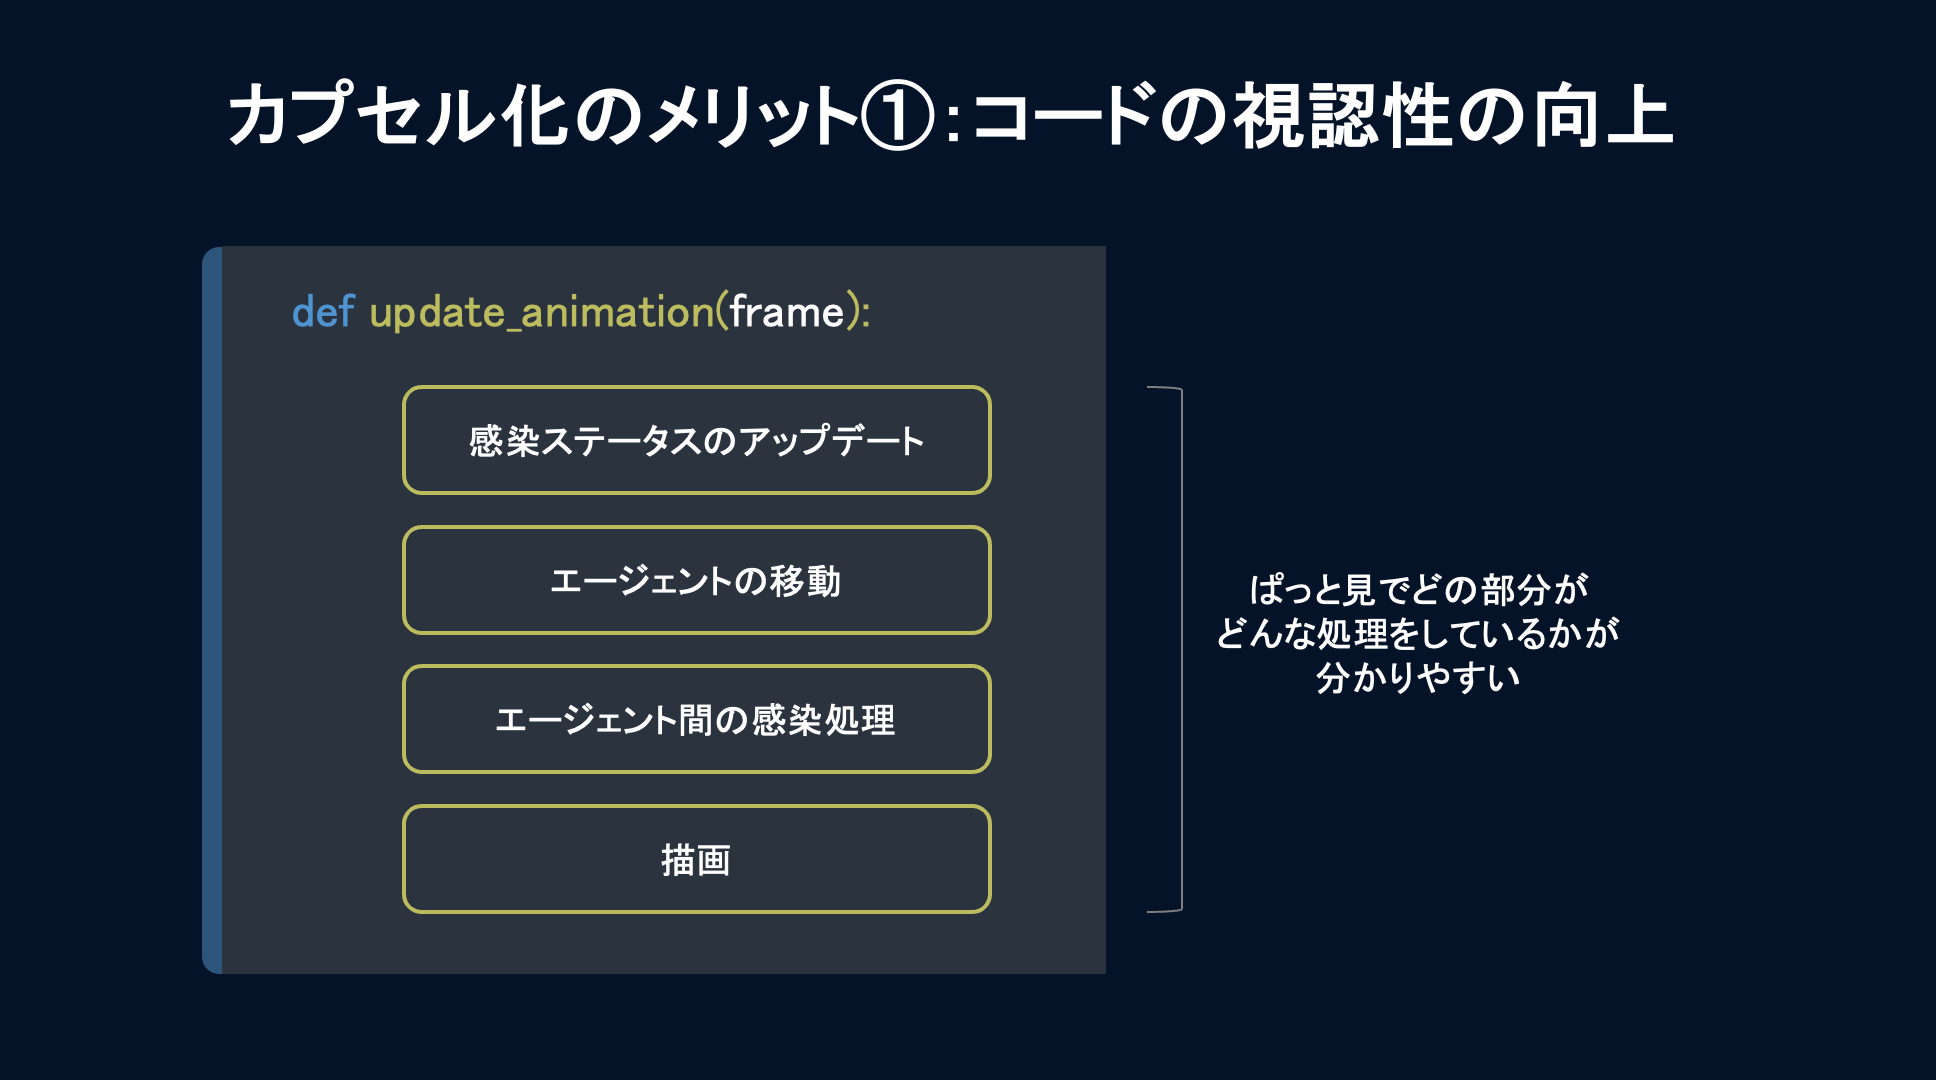

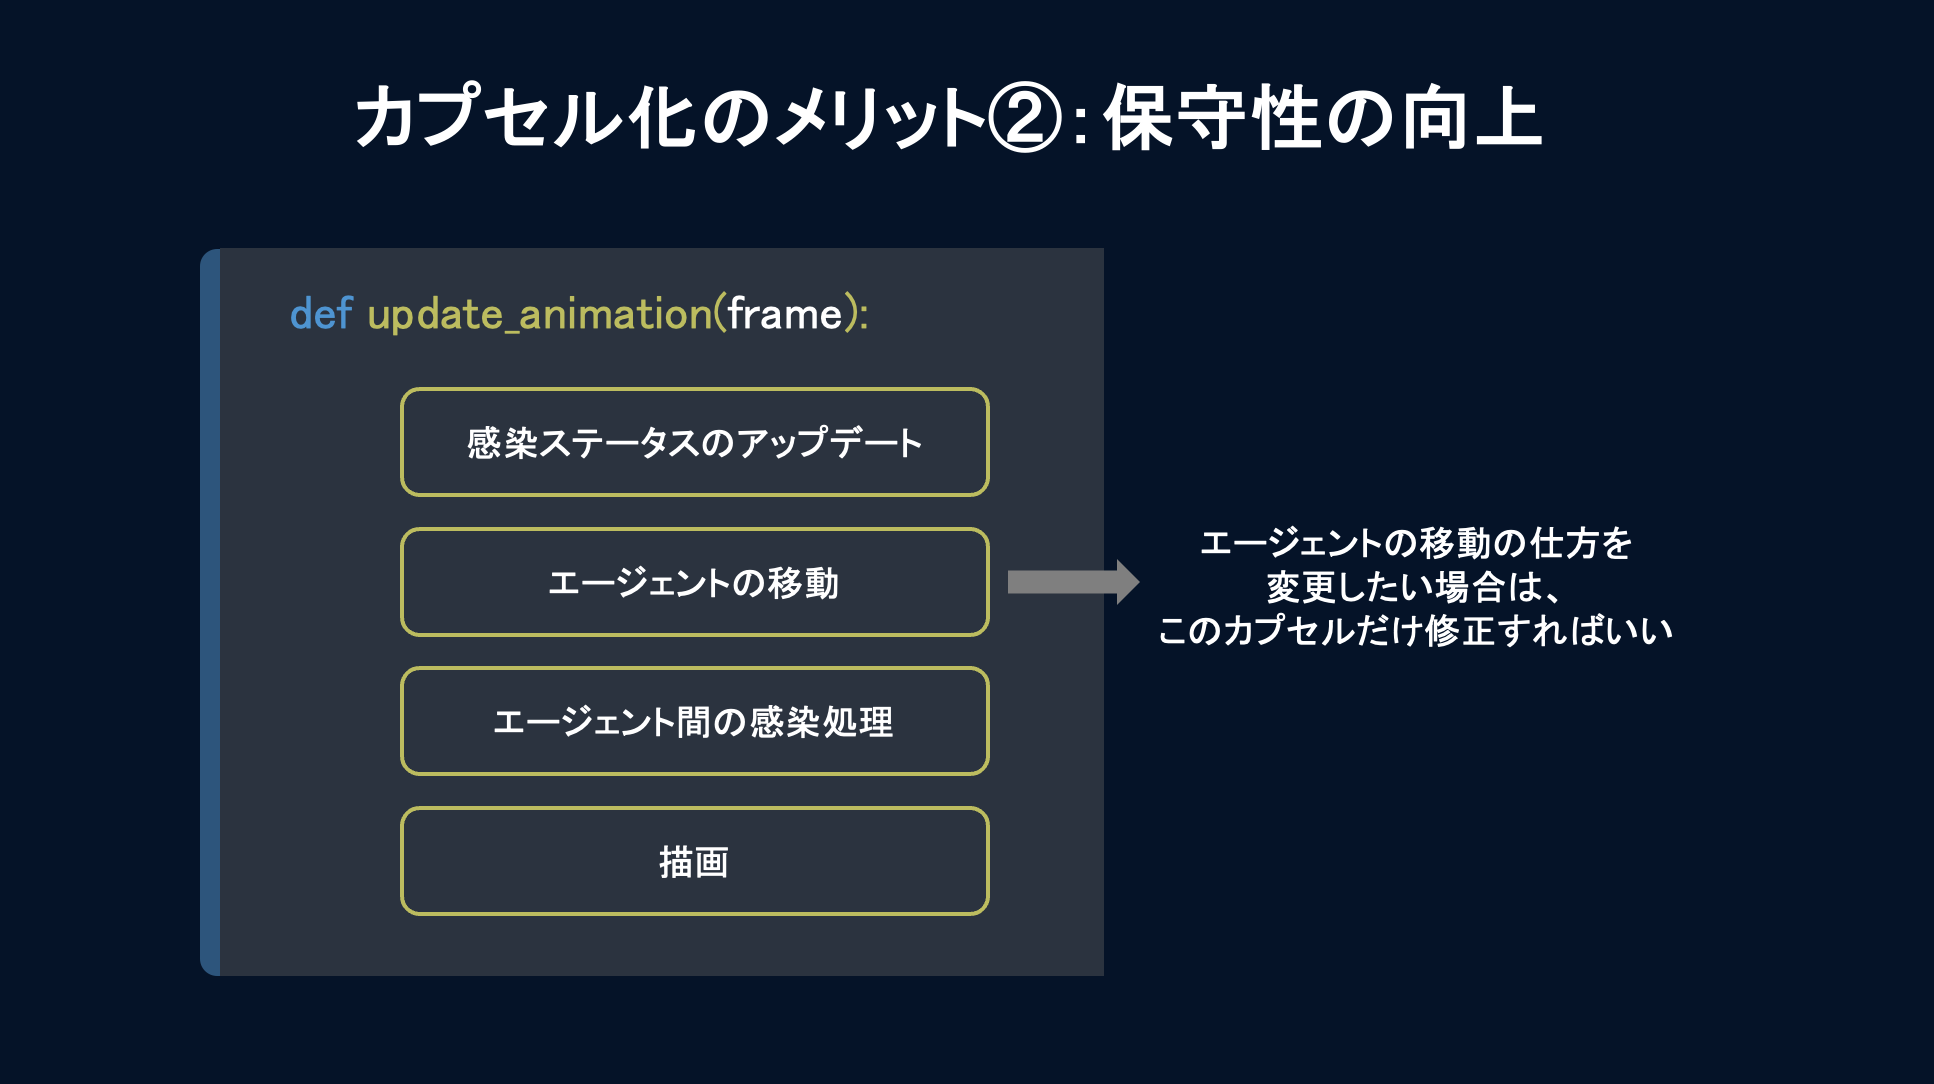

まずは、エージェント間の感染処理の部分を、`spread_infection()`という関数にまとめておきます。

In [ ]:
def spread_infection(agent1, agent2, infection_rate_with_mask, infection_rate_without_mask):
  #感染処理
  infection_rate = calculate_infection_rate(agent1, agent2, infection_rate_with_mask, infection_rate_without_mask)
  if not agent2["is_infected"]:
    if distance_judge(agent1, agent2):
      if random() < infection_rate:
        agent2['is_infected'] = True
  return agent2

次に、キャンバスを準備する部分を、`prepare_canvas()`という関数にまとめておきます。

In [ ]:
def prepare_canvas():
  plt.clf()
  plt.xlim(0, grid_size)
  plt.ylim(0, grid_size)

次に、エージェントを描画する部分を、`scatter_agents()`という関数にまとめておきます。

In [ ]:
def scatter_agents(agent1, agent2):
  for agent in [agent1, agent2]:
    if agent["is_infected"] == True:
      plt.scatter(agent["x"], agent["y"], s=10, color="red", alpha=0.5)
    else:
      plt.scatter(agent["x"], agent["y"], s=10, color="blue", alpha=0.5)

改めてコード全体を書いておきましょう。

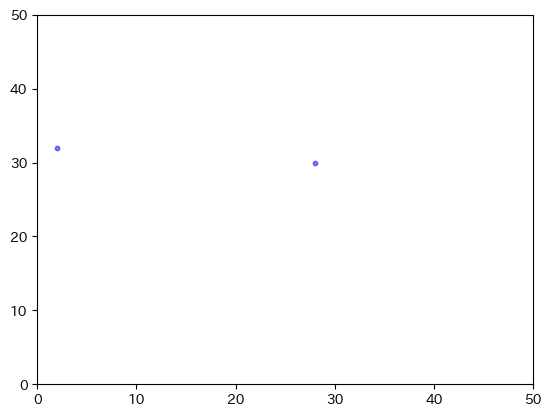

In [ ]:
agent1 = {
    'x': 30,
    'y': 30,
    'dx': 1,
    'dy': 0,
    'is_infected': True,
    'infection_timer': 0,
    'wears_mask': True}

agent2 = {
    'x': 40,
    'y': 32,
    'dx': -1,
    'dy': 0,
    'is_infected': False,
    'infection_timer': 0,
    'wears_mask': False}

#濃厚接触か否かを判定する関数（上下左右2マス以内に近づくと濃厚接触と判定）
def distance_judge(agent1, agent2):
    distance_x = abs(agent1['x'] - agent2['x']) #水平方向の距離を計算
    distance_y = abs(agent1['y'] - agent2['y']) #垂直方向の距離を計算
    #水平方向（左右）で2マス以内かつ垂直方向（上下）で2マス以内にいる場合は濃厚接触(True)と判定
    if distance_x <= 2 and distance_y <= 2:
      return True
    else:
      return False

#人(エージェント)の位置を動かす関数（エージェントは上下左右斜めのいずれかの方向に1マスずつ進む）
def move_agents(agent, grid_size):
  #壁にぶつかっていたら、反対方向に進路を変更
  if agent['x'] == 0 or agent['x'] == grid_size: #左右の壁に当たりそうな場合は逆向きに方向転換
      agent['dx'] *= -1
  if agent["y"] == 0 or agent["y"] == grid_size: #上下の壁に当たりそうな場合は逆向きに方向転換
      agent['dy'] *= -1

  #移動
  agent['x'] += agent['dx'] #エージェントの位置（x座標）を更新
  agent['y'] += agent['dy'] #エージェントの位置（y座標）を更新
  return agent

#マスクの着用状態によって感染率を変更する関数
def calculate_infection_rate(agent1, agent2, infection_rate_with_mask, infection_rate_without_mask):
    #少なくとも一方がマスクをしていたら、マスク着用時感染率（パラメータで指定）を適用。いずれもしていなかったら、通常感染率（パラメータで指定）を適用
    if agent1['wears_mask'] or agent2['wears_mask']:
        return infection_rate_with_mask
    else:
        return infection_rate_without_mask

#人（エージェント）の感染状況を更新する関数（感染してからの経過日を1日プラス。7日経過した場合は治癒）
def update_infection_status(agent):
  if agent['is_infected']:
      agent['infection_timer'] += 1 #感染してからの経過日を1日プラス）
      #感染後7日経過した場合は治癒
      if agent['infection_timer'] >= 7:
          agent['is_infected'] = False #感染ステータスを未感染に変更
          agent['infection_timer'] = 0 #感染経過日のタイマーを0日に修正
  return agent

#濃厚接触の場合にエージェントからエージェントへと一定確率でウィルスを感染させる関数
def spread_infection(agent1, agent2, infection_rate_with_mask, infection_rate_without_mask):
  #マスクの有無によって、感染確率を計算
  infection_rate = calculate_infection_rate(agent1, agent2, infection_rate_with_mask, infection_rate_without_mask)
  if not agent2["is_infected"]:
    if distance_judge(agent1, agent2):
      if random() < infection_rate:
        agent2['is_infected'] = True
  return agent2

#描画用のキャンバスを準備する関数
def prepare_canvas():
  plt.clf() #1コマ前の絵を削除
  plt.xlim(0, grid_size) #x軸のスケールを設定
  plt.ylim(0, grid_size) #y軸のスケールを設定

#エージェントを描画する関数（健常者の場合は青い点、感染者の場合は赤い点で描画）
def scatter_agents(agent1, agent2):
  for agent in [agent1, agent2]:
    if agent["is_infected"] == True:
      plt.scatter(agent["x"], agent["y"], s=10, color="red", alpha=0.5) #感染者の場合は赤い点で描画
    else:
      plt.scatter(agent["x"], agent["y"], s=10, color="blue", alpha=0.5) #健常者の場合は青い点で描画

#1日分シミュレーションを進め、シミュレーション結果を描画する関数（エージェントが移動して新たな感染が発生したり、感染者が回復したりする）
def update_animation(frame, agent1, agent2, infection_rate_with_mask, infection_rate_without_mask, grid_size):
  #各エージェントの感染状況のアップデート
  agent1 = update_infection_status(agent1) #コロナウィルスを移す側
  agent2 = update_infection_status(agent2) #コロナウィルスを移される側

  #各エージェントの移動
  agent1 = move_agents(agent1, grid_size)
  agent2 = move_agents(agent2, grid_size)

  #エージェント1からエージェント2への感染処理
  agent2 = spread_infection(agent1, agent2, infection_rate_with_mask, infection_rate_without_mask)

  #キャンバスの描画
  prepare_canvas()

  #agent1とagent2の描画
  scatter_agents(agent1, agent2)

#各種パラメータの設定（ここでシミュレーションモデルのパラメータを変更できます）
grid_size = 50
steps = 40
infection_rate_with_mask = 0.1
infection_rate_without_mask = 0.8

# アニメーションの作成
fig = plt.figure()
ani = FuncAnimation(fig, update_animation, fargs=(agent1, agent2, infection_rate_with_mask, infection_rate_without_mask, grid_size), frames=range(steps), interval=100)

# アニメーションの表示
HTML(ani.to_jshtml())

これでLevel3は終了です。<br>
Level4では、1,000人のエージェントを動かしてシミュレーションしていきます。